# Cost of Wind Energy Review: 2025 Edition
This notebook runs the WAVES model and saves results to intermediate .csv files which can be used for plotting in the Annual Reporting Workflow.
https://github.com/dmulash/Annual_Reporting_Workflow/tree/main

**National Renewable Energy Laboratory**  
**Daniel Mulas Hernando, daniel.mulashernando@nrel.gov**

Builds on previous notebooks from:
- **Nick Riccobono, nicholas.riccobono@nrel.gov**
- **Rob Hammond, rob.hammond@nrel.gov**

**21 November 2025**

These simulations were performed using the following software versions:

- **ORBIT** v1.2.4  
  - *Note:* The *dev* branch of ORBIT as of 19 November 2025 was used, which includes unreleased features beyond v1.2.4. If a newer release (e.g., v1.2.5) becomes available at the time of publication, we recommend using that version to ensure full reproducibility.
- **WOMBAT** v0.12.2
  - *Note:* The *develop* branch of WOMBAT as of 19 November 2025 was used, which includes unreleased features beyond v0.12.2. If a newer release (e.g., v0.13) becomes available at the time of publication, we recommend using that version to ensure full 
- **FLORIS** v4.5.1  
- **WAVES** v0.6.1  

This notebook runs WAVES for the number of simulations specified in `N_RUNS`, applying consistent `random_seed` values in the WOMBAT configuration files to ensure results are fully reproducible.

In [1]:
from copy import deepcopy
from time import perf_counter
from pathlib import Path

import numpy as np
import pandas as pd

from waves import Project
from waves.utilities import load_yaml

# Update core Pandas display settings
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

In [2]:
def run_waves(project):
    start2 = perf_counter()
    project.run(full_wind_rose=False)
    project.wombat.env.cleanup_log_files()  # Delete logging data from the WOMBAT simulations
    end2 = perf_counter()
    
    print("-" * 29)  # separate our timing from the ORBIT and FLORIS run-time warnings
    print(f"Run time: {end2 - start2:,.2f} seconds")

    return project

def average_and_save(dfs, filename, index_col=None):
    """
    Safely averages a list of DataFrames and saves to CSV.
    Ensures numeric columns are averaged, non-numeric columns are preserved,
    and indices/assumptions are aligned correctly.
    """

    import pandas as pd
    import numpy as np

    # Make deep copies so original DataFrames are untouched
    dfs_copy = [df.copy() for df in dfs]

    # If index_col is provided, ensure it is index in all DataFrames
    if index_col:
        dfs_copy = [
            df.set_index(index_col) if index_col in df.columns else df
            for df in dfs_copy
        ]

    # Concatenate vertically
    df_concat = pd.concat(dfs_copy, axis=0, ignore_index=False)

    # -----------------------------
    # FIX: Ensure numeric columns are actually numeric
    # -----------------------------
    for col in df_concat.columns:
        if col.lower() == "value":
            df_concat[col] = (
                df_concat[col]
                .astype(str)
                .str.replace(",", "", regex=False)  # remove commas
                .replace("", np.nan)               # blank → NaN
            )
            # Convert to float where possible
            df_concat[col] = pd.to_numeric(df_concat[col], errors="coerce")

    # Identify numeric and non-numeric columns
    numeric_cols = df_concat.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = df_concat.select_dtypes(exclude=[np.number]).columns.tolist()

    # Group by the index (Assumption, Component, etc.)
    group_index = df_concat.index

    # Average numeric columns
    df_numeric_avg = df_concat[numeric_cols].groupby(group_index).mean()

    # Keep the first non-numeric entry (Assumption name, Units, etc.)
    df_non_numeric = df_concat[non_numeric_cols].groupby(group_index).first()

    # Combine back together
    df_avg = pd.concat([df_non_numeric, df_numeric_avg], axis=1)

    # Keep index clean
    if index_col:
        df_avg.index.name = index_col

    # Save to CSV
    df_avg.to_csv(filename)
    print(f"Saved: {filename}")

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy
from time import perf_counter

# ======================================================
# USER SETTINGS
# ======================================================

NUM_RUNS = 50
RANDOM_SEEDS = list(range(1, NUM_RUNS + 1))

# Where results will be saved
results_root = Path("../library/base_2024/results")

# ======================================================
# FUNCTION TO RUN ALL SEEDS FOR A TECHNOLOGY
# ======================================================

def run_technology(config_base: dict, tech_name: str):
    """
    Runs NUM_RUNS simulations for a given technology configuration
    (fixed or floating) and saves average CSVs for the five key dataframes.
    """

    print(f"\n===== RUNNING {tech_name.upper()} CASE =====")

    # Output containers
    capex_dfs = []
    opex_dfs = []
    equipment_cost_dfs = []
    report_dfs = []
    losses_dfs = []
    lcoe_dfs = []
    project_details_dfs = []

    for i, seed in enumerate(RANDOM_SEEDS):

        print(f"\nRun {i+1}/{NUM_RUNS} ({tech_name}, seed={seed})")

        # Fresh deep copy
        config = deepcopy(config_base)

        # Load and insert operations config
        operations_config_name = config["wombat_config"]
        operations_config_path = config["library_path"] / "project/config"
        config_operations = load_yaml(operations_config_path, operations_config_name)
        config_operations["random_seed"] = seed
        config["wombat_config"] = config_operations

        # Load project
        start = perf_counter()
        project = Project.from_dict(config)
        print(f"Loading time: {perf_counter() - start:,.2f} seconds")

        # Run simulation (waves, failures, repairs, etc.)
        project = run_waves(project)

        metrics = project.wombat.metrics
        years = project.wombat.env.simulation_years

        # --------------------------
        # CAPEX
        # --------------------------
        df_capex = pd.DataFrame(
            project.orbit.capex_detailed_soft_capex_breakdown.items(),
            columns=["Component", f"CapEx ($) - {tech_name}"]
        )
        df_capex[f"CapEx ($/kW) - {tech_name}"] = (
            df_capex[f"CapEx ($) - {tech_name}"] / project.capacity("kw")
        )
        df_capex.set_index("Component", inplace=True)
        capex_dfs.append(df_capex)

        # --------------------------
        # OPEX
        # --------------------------
        opex_df = metrics.opex(frequency="annual", by_category=True)
        opex_dfs.append(opex_df)

        # --------------------------
        # Equipment Costs
        # --------------------------
        equip_df = metrics.equipment_costs(frequency="annual", by_equipment=True)
        equipment_cost_dfs.append(equip_df)

        # --------------------------
        # lCOE breakdown for waterfall plot
        # --------------------------
        lcoe_df = project.generate_report_lcoe_breakdown()
        lcoe_dfs.append(lcoe_df)

        # --------------------------
        # Project details
        # --------------------------
        project_details_df = project.generate_report_project_details()
        project_details_dfs.append(project_details_df)
        
        # --------------------------
        # Report DF
        # --------------------------
        report_df = project.generate_cost_report()
        report_dfs.append(report_df)

        # --------------------------
        # Losses Report
        # --------------------------
        losses_df = project.loss_ratio(breakdown=True)
        losses_dfs.append(losses_df)

    # ======================================================
    # SAVE RESULTS FOR THIS TECHNOLOGY
    # ======================================================

    tech_dir = results_root / tech_name
    tech_dir.mkdir(parents=True, exist_ok=True)

    average_and_save(capex_dfs, tech_dir / "average_capex.csv")
    average_and_save(opex_dfs, tech_dir / "average_opex.csv")
    average_and_save(equipment_cost_dfs, tech_dir / "average_equipment_costs.csv")
    average_and_save(report_dfs, tech_dir / "average_report_df.csv")
    average_and_save(lcoe_dfs, tech_dir / "average_lcoe_breakdown.csv")
    average_and_save(project_details_dfs, tech_dir / "average_project_details.csv")
    average_and_save(losses_dfs, tech_dir / "average_losses_report_df.csv")

    print(f"\n>>> Saved results under: {tech_dir}\n")

In [4]:
# ======================================================
# LOAD TECHNOLOGY CONFIGS
# ======================================================

library_path = Path("../library/base_2024/")

config_fixed = load_yaml(library_path / "project/config", "base_fixed_bottom_2024.yaml")
config_floating = load_yaml(library_path / "project/config", "base_floating_2024.yaml")

config_fixed.update({"library_path": library_path})
config_floating.update({"library_path": library_path})

# ======================================================
# RUN BOTH TECHNOLOGIES
# ======================================================

run_technology(config_fixed, tech_name="fixed")
run_technology(config_floating, tech_name="floating")


===== RUNNING FIXED CASE =====

Run 1/50 (fixed, seed=1)
ORBIT library intialized at 'C:\WAVES_COWER_2025_python_3_11\WAVES\library\base_2024'
No LandBOSSE configuration provided, skipping model setup.


Missing data in columns ['cable_length', 'bury_speed']; all values will be calculated.UserWarning: C:\Users\dmulash\.conda\envs\WAVES_COWER_2025_python_3_11\Lib\site-packages\ORBIT\phases\design\array_system_design.py:1088
Missing data in columns ['cable_length', 'bury_speed']; all values will be calculated.

Loading time: 6.77 seconds


invalid value encountered in divideRuntimeWarning: C:\Users\dmulash\.conda\envs\WAVES_COWER_2025_python_3_11\Lib\site-packages\floris\core\wake_deflection\gauss.py:498
invalid value encountered in divide

-----------------------------
Run time: 331.71 seconds

Run 2/50 (fixed, seed=2)
No LandBOSSE configuration provided, skipping model setup.


...

No LandBOSSE configuration provided, skipping model setup.


DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.UserWarning: C:\Users\dmulash\.conda\envs\WAVES_COWER_2025_python_3_11\Lib\site-packages\ORBIT\phases\design\array_system_design.py:1088
Missing data in columns ['bury_speed']; all values will be calculated.UserWarning: C:\Users\dmulash\.conda\envs\WAVES_COWER_2025_python_3_11\Lib\site-packages\ORBIT\phases\design\array_system_design.py:1088
Missing data in columns ['bury_speed']; all values will be calculated.

Loading time: 5.78 seconds


invalid value encountered in divideRuntimeWarning: C:\Users\dmulash\.conda\envs\WAVES_COWER_2025_python_3_11\Lib\site-packages\floris\core\wake_deflection\gauss.py:498
invalid value encountered in divide

-----------------------------
Run time: 253.63 seconds
Saved: ..\library\base_2024\results\floating\average_capex.csv
Saved: ..\library\base_2024\results\floating\average_opex.csv
Saved: ..\library\base_2024\results\floating\average_equipment_costs.csv
Saved: ..\library\base_2024\results\floating\average_report_df.csv
Saved: ..\library\base_2024\results\floating\average_lcoe_breakdown.csv
Saved: ..\library\base_2024\results\floating\average_project_details.csv
Saved: ..\library\base_2024\results\floating\average_losses_report_df.csv

>>> Saved results under: ..\library\base_2024\results\floating



# COWER Plots

In [5]:
import COWER
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Fixed-Bottom Offshore Wind GPRA Figure

118.87070468240952
LCOE ($/MWh. 2024 USD): 118.87070468240952


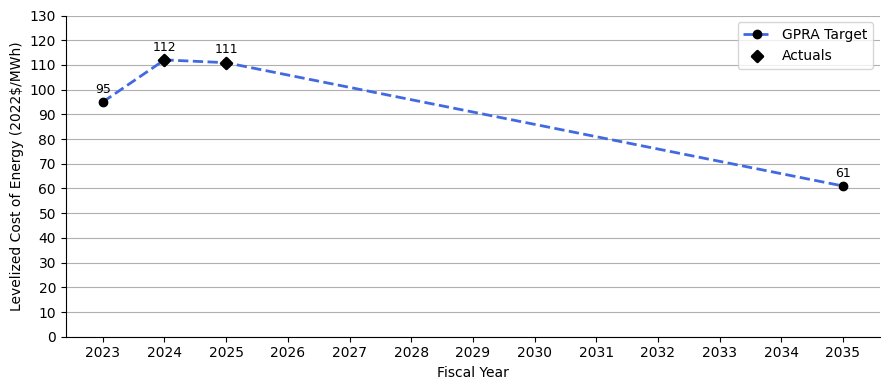

In [6]:
results_root = Path("../library/base_2024/results")
file_path = results_root / "fixed" / "average_report_df.csv"

# Read CSV
df = pd.read_csv(file_path)

# Drop unnamed index column if present
if df.columns[0].startswith("Unnamed"):
    df = df.drop(columns=df.columns[0])

# Extract the LCOE value and set other values from previous years and inflation parameters
lcoe_value_2025 = df.loc[df["Assumption"] == "LCOE"]["Value"].iloc[0] # 2024 USD
print(lcoe_value_2025)
lcoe_value_2024 = 116.635672452994  # 2023 USD
lcoe_value_2023 = 95  # 2022 USD
CPI_2024 = 313.688
CPI_2023 = 304.702
CPI_2022 = 292.655
GPRA_target_2035 = 61 # 2022 USD

print("LCOE ($/MWh. 2024 USD):", lcoe_value_2025)

target = [(lcoe_value_2023, 2023), (lcoe_value_2024*CPI_2022/CPI_2023, 2024),(lcoe_value_2025*CPI_2022/CPI_2024, 2025), (GPRA_target_2035,  2035)]
#old_target = (60, 2030)
actuals = [(lcoe_value_2024*CPI_2022/CPI_2023, 2024), (lcoe_value_2025*CPI_2022/CPI_2024, 2025)]

COWER.plot_GPRA_data("GPRA_FBOW",target, actuals)


## LCOE Waterfall Plots

In [7]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_lcoe_breakdown.csv"
file_path_floating = results_root / "floating" / "average_lcoe_breakdown.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

display(df_fixed)
display(df_floating)

,Unnamed: 0,Component,Category,Value ($/kW),Fixed charge rate (FCR) (real),Value ($/kW-yr),Net AEP (MWh/kW/yr),Value ($/MWh)
0,0,Turbine,Turbine,"1,770.00",0.06,112.97,4.32,26.13
1,1,Array System,Balance of System CapEx,382.63,0.06,24.42,4.32,5.65
2,2,Export System,Balance of System CapEx,295.35,0.06,18.85,4.32,4.36
3,3,Offshore Substation,Balance of System CapEx,373.17,0.06,23.82,4.32,5.51
4,4,Scour Protection,Balance of System CapEx,8.91,0.06,0.57,4.32,0.13
5,5,Substructure,Balance of System CapEx,710.41,0.06,45.34,4.32,10.49
6,6,Array System Installation,Balance of System CapEx,275.20,0.06,17.56,4.32,4.06
7,7,Export System Installation,Balance of System CapEx,229.09,0.06,14.62,4.32,3.38
8,8,Offshore Substation Installation,Balance of System CapEx,8.52,0.06,0.54,4.32,0.13
9,9,Scour Protection Installation,Balance of System CapEx,35.08,0.06,2.24,4.32,0.52


,Unnamed: 0,Component,Category,Value ($/kW),Fixed charge rate (FCR) (real),Value ($/kW-yr),Net AEP (MWh/kW/yr),Value ($/MWh)
0,0,Turbine,Turbine,"1,770.00",0.07,124.99,3.98,31.44
1,1,Array System,Balance of System CapEx,466.84,0.07,32.96,3.98,8.29
2,2,Export System,Balance of System CapEx,267.67,0.07,18.90,3.98,4.75
3,3,Substructure,Balance of System CapEx,"1,334.57",0.07,94.24,3.98,23.70
4,4,Mooring System,Balance of System CapEx,565.92,0.07,39.96,3.98,10.05
5,5,Offshore Substation,Balance of System CapEx,371.65,0.07,26.24,3.98,6.60
6,6,Array System Installation,Balance of System CapEx,468.89,0.07,33.11,3.98,8.33
7,7,Export System Installation,Balance of System CapEx,265.10,0.07,18.72,3.98,4.71
8,8,Substructure Installation,Balance of System CapEx,143.45,0.07,10.13,3.98,2.55
9,9,Mooring System Installation,Balance of System CapEx,147.12,0.07,10.39,3.98,2.61


### Manual Post-Processing for Categories and Grouping
Go to 'library/base_2024/results/fixed/average_lcoe_breakdown.csv' and 'library/base_2024/results/floating/average_lcoe_breakdown.csv', and manually update the post-processed csv to "average_lcoe_breakdown_pp.csv" so that it is in line with the categories from the COWER 

,Component,Category,Value ($/kW),Fixed charge rate (FCR) (real),Value ($/kW-yr),Net AEP (MWh/kW/yr),Value ($/MWh)
0,Turbine,Turbine,"1,770.00",0.06,112.97,4.32,26.13
1,Array System,Balance of System CapEx,382.63,0.06,24.42,4.32,5.65
2,Export System,Balance of System CapEx,295.35,0.06,18.85,4.32,4.36
3,Offshore Substation,Balance of System CapEx,373.17,0.06,23.82,4.32,5.51
4,Scour Protection,Balance of System CapEx,8.91,0.06,0.57,4.32,0.13
5,Substructure,Balance of System CapEx,710.41,0.06,45.34,4.32,10.49
6,Onshore Substation,Balance of System CapEx,166.51,0.06,10.63,4.32,2.46
7,Installation,Balance of System CapEx,780.95,0.06,49.84,4.32,11.53
8,Lease Price,Balance of System CapEx,9.27,0.06,0.59,4.32,0.14
9,Project Development,Balance of System CapEx,266.67,0.06,17.02,4.32,3.94


,Unnamed: 0,Component,Category,Value ($/kW),Fixed charge rate (FCR) (real),Value ($/kW-yr),Net AEP (MWh/kW/yr),Value ($/MWh)
0,0.00,Turbine,Turbine,"1,770.00",0.07,124.99,3.98,31.44
1,1.00,Array System,Balance of System CapEx,466.84,0.07,32.96,3.98,8.29
2,2.00,Export System,Balance of System CapEx,267.67,0.07,18.90,3.98,4.75
3,3.00,Substructure,Balance of System CapEx,"1,334.57",0.07,94.24,3.98,23.70
4,4.00,Mooring System,Balance of System CapEx,565.92,0.07,39.96,3.98,10.05
5,5.00,Offshore Substation,Balance of System CapEx,371.65,0.07,26.24,3.98,6.60
6,11.00,Onshore Substation,Balance of System CapEx,164.66,0.07,11.63,3.98,2.92
7,NaN,Installation,Balance of System CapEx,"1,038.18",0.07,73.31,3.98,18.44
8,NaN,Lease Price,Balance of System CapEx,172.53,0.07,12.18,3.98,3.06
9,NaN,Project Development,Balance of System CapEx,266.67,0.07,18.83,3.98,4.74


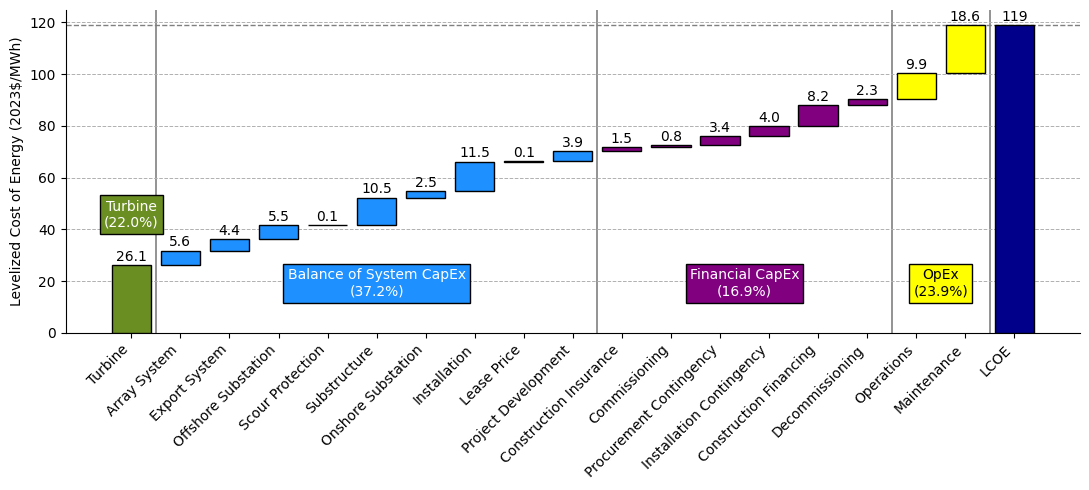

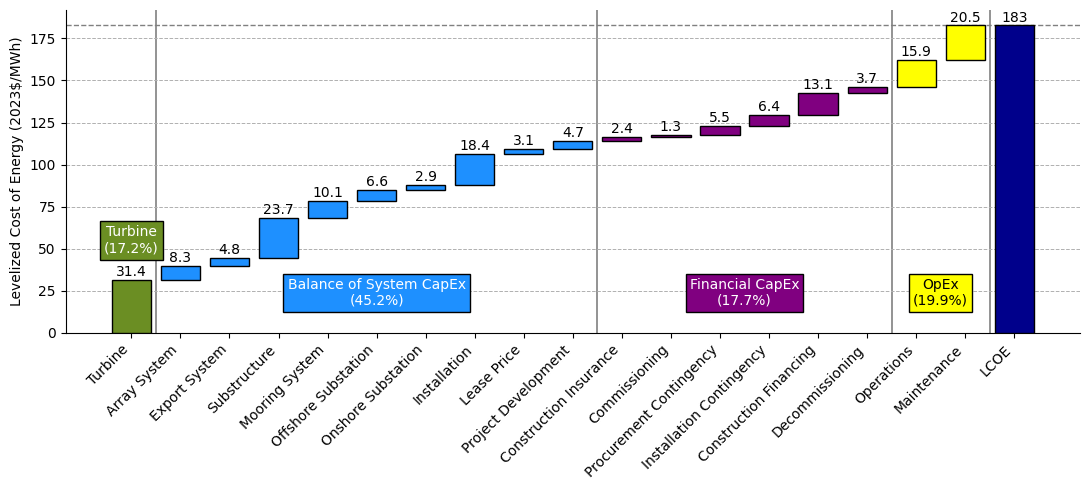

In [8]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_lcoe_breakdown_pp.csv"
file_path_floating = results_root / "floating" / "average_lcoe_breakdown_pp.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

#display post-processed csvs
display(df_fixed)
display(df_floating)

#plot LCOE waterfalls
COWER.plot_LCOE_waterfall("FBOW", df_fixed, 11, 5)
COWER.plot_LCOE_waterfall("FLOW", df_floating, 11, 5)

# CapEx Donut Plots

In [9]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_capex.csv"
file_path_floating = results_root / "floating" / "average_capex.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

display(df_fixed)
display(df_floating)

,Component,CapEx ($) - fixed,CapEx ($/kW) - fixed
0,Array System,"229,580,101.77",382.63
1,Array System Installation,"165,119,369.39",275.20
2,Commissioning,"32,870,630.26",54.78
3,Construction Financing,"332,340,281.42",553.90
4,Construction Insurance,"59,167,134.46",98.61
5,Decommissioning,"93,713,494.31",156.19
6,Export System,"177,208,497.34",295.35
7,Export System Installation,"137,456,836.78",229.09
8,Installation Contingency,"161,655,777.68",269.43
9,Offshore Substation,"223,904,483.10",373.17


,Component,CapEx ($) - floating,CapEx ($/kW) - floating
0,Array System,"280,103,447.08",466.84
1,Array System Installation,"281,336,257.72",468.89
2,Commissioning,"44,288,888.42",73.81
3,Construction Financing,"443,124,925.74",738.54
4,Construction Insurance,"79,719,999.15",132.87
5,Decommissioning,"124,581,310.39",207.64
6,Export System,"160,602,563.75",267.67
7,Export System Installation,"159,057,857.16",265.10
8,Installation Contingency,"214,902,760.43",358.17
9,Mooring System,"339,550,977.65",565.92


### Manual Post-Processing for Categories and Grouping, Adding Colors, Re-Adjust Ordering so that Labels are not Clustered
Go to 'library/base_2024/results/fixed/average_capex.csv' and 'library/base_2024/results/floating/average_capex.csv', and manually update the post-processed csv to "average_capex.csv_pp.csv" so that it is in line with the categories from the COWER 

,Component,Category,Value ($/kW),Color
0,Construction Insurance,Soft Costs,98.61,m
1,Decommissioning,Soft Costs,156.19,rebeccapurple
2,Construction Financing,Soft Costs,553.90,darkviolet
3,Procurement Contingency,Soft Costs,229.02,mediumorchid
4,Install. Contingency,Soft Costs,269.43,darkmagenta
5,Commissioning,Soft Costs,54.78,palevioletred
6,Array System,Balance of System,382.63,deepskyblue
7,Export System,Balance of System,295.35,darkturquoise
8,Offshore Substation,Balance of System,373.17,dodgerblue
9,Substructure,Balance of System,710.41,darkblue


,Component,Category,Value ($/kW),Color
0,Construction Insurance,Soft Costs,132.87,m
1,Decommissioning,Soft Costs,207.64,rebeccapurple
2,Construction Financing,Soft Costs,738.54,darkviolet
3,Procurement Contingency,Soft Costs,309.38,mediumorchid
4,Install. Contingency,Soft Costs,358.17,palevioletred
5,Commissioning,Soft Costs,73.81,darkmagenta
6,Array System,Balance of System,466.84,deepskyblue
7,Export System,Balance of System,267.67,darkturquoise
8,Offshore Substation,Balance of System,371.65,dodgerblue
9,Substructure,Balance of System,"1,334.57",lightseagreen


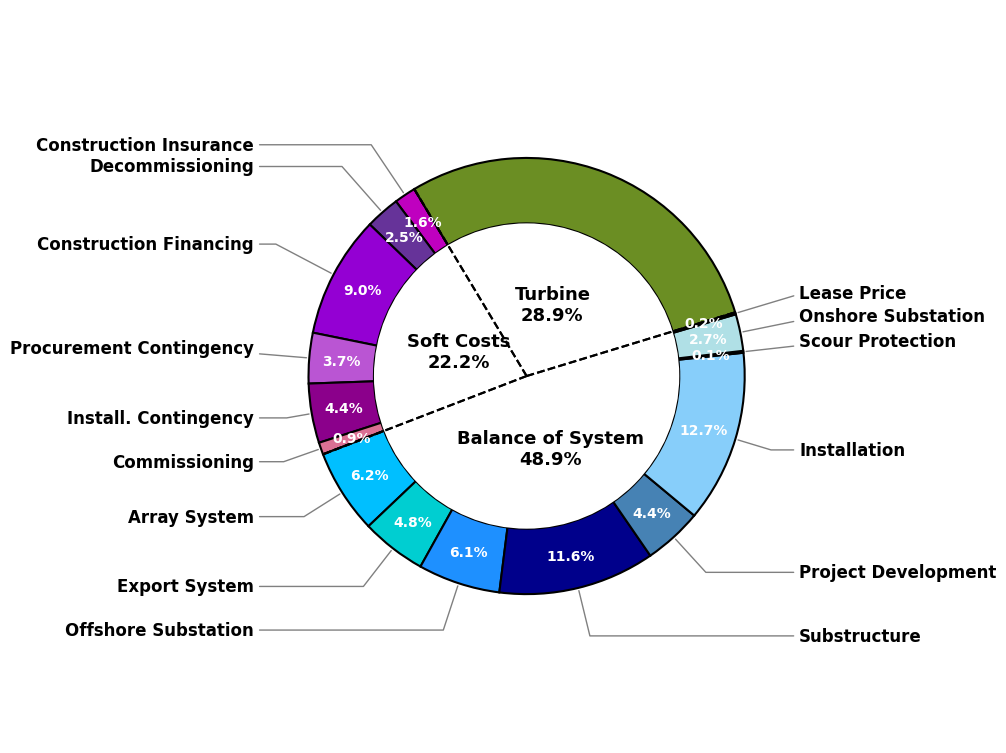

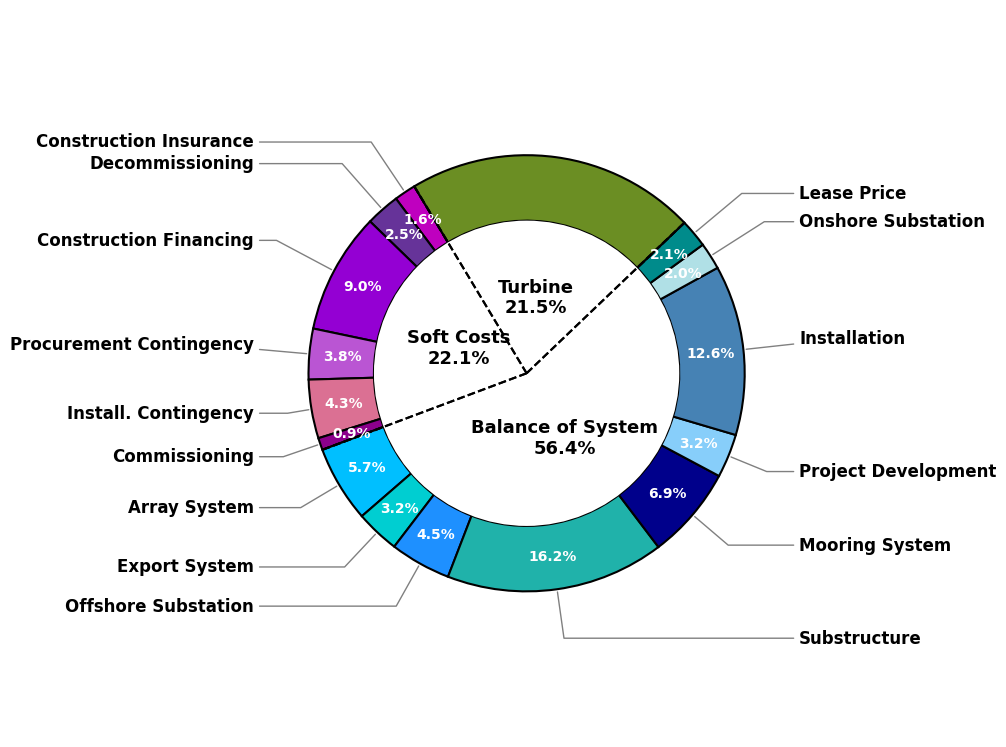

In [10]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_capex_pp.csv"
file_path_floating = results_root / "floating" / "average_capex_pp.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

#display post-processed csvs
display(df_fixed)
display(df_floating)

#plot LCOE waterfalls
COWER.plot_capex_donut("FBOW", df_fixed, 121, 10, 8)
COWER.plot_capex_donut("FLOW", df_floating, 121, 10, 8)

# LCOE Tornado Plots

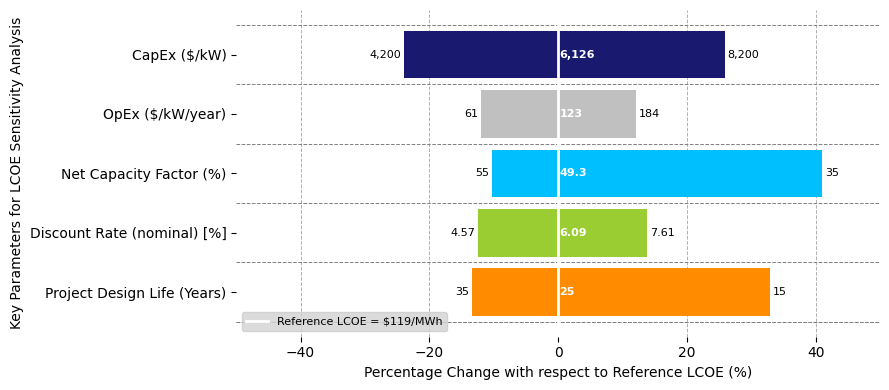

In [11]:
df = pd.read_csv("Data/FBOW_Sensitivity.csv")
COWER.plot_LCOE_sensitivity_percentage("FBOW", df, 9, 4, -50, 50)

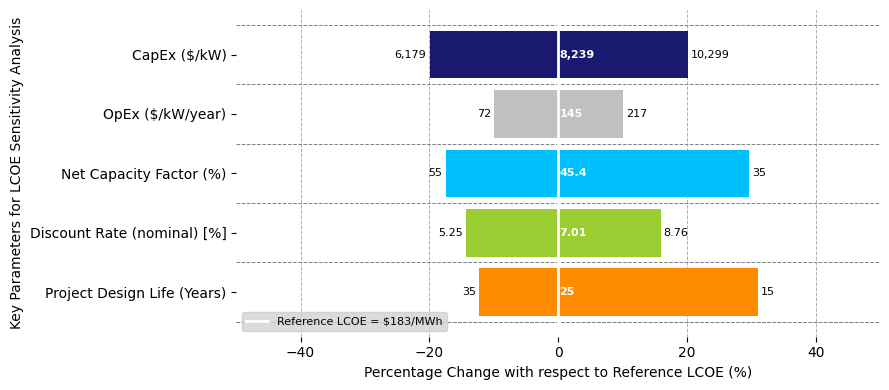

In [12]:
df = pd.read_csv("Data/FLOW_Sensitivity.csv")
COWER.plot_LCOE_sensitivity_percentage("FLOW", df, 9, 4, -50, 50)

# Project Details Table (Appendix)

In [13]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_project_details.csv"
file_path_floating = results_root / "floating" / "average_project_details.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

#display post-processed csvs
display(df_fixed)
display(df_floating)

,Unnamed: 0,Assumption,Units,Value
0,0,Wind plant capacity,MW,600.00
1,1,Number of turbines,Number,50.00
2,2,Turbine rating,MW,12.00
3,3,Rotor diameter,m,216.45
4,4,Hub height,m,137.00
5,5,Specific power,W/m2,326.12
6,6,Water depth,m,34.00
7,7,Substructure type,-,NaN
8,8,Distance to port,km,116.00
9,9,Distance to landfall,km,50.00


,Unnamed: 0,Assumption,Units,Value
0,0,Wind plant capacity,MW,600.00
1,1,Number of turbines,Number,50.00
2,2,Turbine rating,MW,12.00
3,3,Rotor diameter,m,216.45
4,4,Hub height,m,137.00
5,5,Specific power,W/m2,326.12
6,6,Water depth,m,739.00
7,7,Substructure type,-,NaN
8,8,Distance to port,km,189.00
9,9,Distance to landfall,km,36.00


In [14]:
results_root = Path("../library/base_2024/results")
file_path_fixed = results_root / "fixed" / "average_report_df.csv"
file_path_floating = results_root / "floating" / "average_report_df.csv"

# Read CSV
df_fixed = pd.read_csv(file_path_fixed)
df_floating = pd.read_csv(file_path_floating)

#display post-processed csvs
display(df_fixed)
display(df_floating)

,Unnamed: 0,Assumption,Units,Value
0,0,CapEx per kW,$/kW,"6,125.79"
1,1,Annual OpEx per kW,$/kW-yr,122.95
2,2,FCR,%,6.38
3,3,Total system losses,%,17.24
4,4,Availability,%,93.94
5,5,Gross AEP,MWh/kW/yr,5.22
6,6,Net AEP,MWh/kW/yr,4.32
7,7,Gross Capacity Factor,%,59.60
8,8,Net Capacity Factor,%,49.32
9,9,LCOE,$/MWh,118.87


,Unnamed: 0,Assumption,Units,Value
0,0,CapEx per kW,$/kW,"8,239.09"
1,1,Annual OpEx per kW,$/kW-yr,144.60
2,2,FCR,%,7.06
3,3,Total system losses,%,19.99
4,4,Availability,%,92.00
5,5,Gross AEP,MWh/kW/yr,4.97
6,6,Net AEP,MWh/kW/yr,3.98
7,7,Gross Capacity Factor,%,56.69
8,8,Net Capacity Factor,%,45.36
9,9,LCOE,$/MWh,182.70
